# Ensemble Learning: Random Forest Classifier on the Iris Dataset

---

## Introduction

**Random Forest** is an ensemble of Decision Trees where each tree is trained on a bootstrap sample of the training data and uses a random subset of features at every split node. Predictions are combined via majority vote. The result is a model with significantly lower variance than a single Decision Tree, strong generalization, and built-in feature importance scores.

This notebook applies `RandomForestClassifier` to the **Iris dataset** — a 3-class classification benchmark with 150 samples and 4 features — and covers the complete workflow from data exploration to hyperparameter tuning.

### Workflow

1. Load and explore the Iris dataset
2. Preprocess and split into train / test sets
3. Establish a baseline with a single `DecisionTreeClassifier`
4. Train a `RandomForestClassifier` and evaluate with confusion matrix and classification report
5. Visualize feature importances
6. Tune hyperparameters using `GridSearchCV`
7. Compare all models in a results summary

---

## 1. Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

---

## 2. Loading and Exploring the Dataset

The Iris dataset contains 150 samples from three species of iris flowers, each described by four measurements.

| Feature | Description |
|---|---|
| `sepal length (cm)` | Length of the sepal |
| `sepal width (cm)` | Width of the sepal |
| `petal length (cm)` | Length of the petal |
| `petal width (cm)` | Width of the petal |
| `target` | Species: 0 = setosa, 1 = versicolor, 2 = virginica |

In [2]:
iris = load_iris()

df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target
df['species'] = df['target'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

print('Shape:', df.shape)
print('\nClass distribution:')
print(df['species'].value_counts())
df.head()

Shape: (150, 6)

Class distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [3]:
df.describe().round(2)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.00,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20,1.00
std,0.83,0.44,1.77,0.76,0.82
min,4.30,2.00,1.00,0.10,0.00
25%,5.10,2.80,1.60,0.30,0.00
50%,5.80,3.00,4.35,1.30,1.00
75%,6.40,3.30,5.10,1.80,2.00
max,7.90,4.40,6.90,2.50,2.00


### 2.1 Pairplot — Feature Relationships by Species

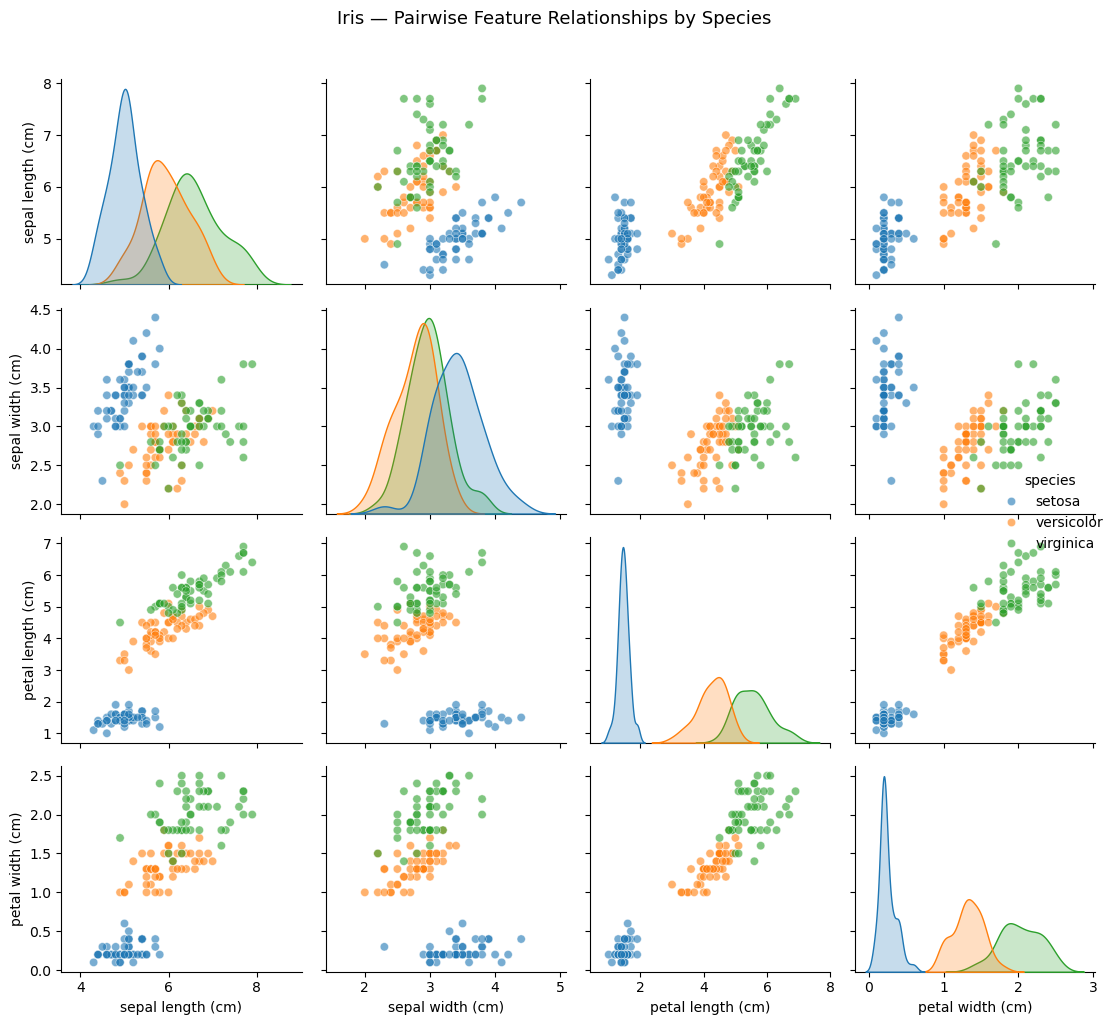

In [4]:
sns.pairplot(df.drop(columns='target'), hue='species', diag_kind='kde', plot_kws={'alpha': 0.6})
plt.suptitle('Iris — Pairwise Feature Relationships by Species', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

---

## 3. Preprocessing and Train / Test Split

We use all four features and hold out 20% of data as the test set. The split is stratified to preserve class proportions in both sets.

In [5]:
X = df[iris.feature_names].values
y = df['target'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train : {X_train.shape[0]} samples')
print(f'Test  : {X_test.shape[0]} samples')

Train : 120 samples
Test  : 30 samples


---

## 4. Baseline: Single Decision Tree

An unpruned `DecisionTreeClassifier` serves as our baseline. Decision trees are high-variance models — they fit the training data perfectly but often overfit, leading to lower test accuracy.

In [6]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
acc_dt = accuracy_score(y_test, y_pred_dt)

print(f'Decision Tree — Train Accuracy : {dt.score(X_train, y_train):.4f}')
print(f'Decision Tree — Test Accuracy  : {acc_dt:.4f}')

Decision Tree — Train Accuracy : 1.0000
Decision Tree — Test Accuracy  : 0.9333


---

## 5. Random Forest Classifier

### 5.1 Training

In [7]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)

print(f'Random Forest — Train Accuracy : {rf.score(X_train, y_train):.4f}')
print(f'Random Forest — Test Accuracy  : {acc_rf:.4f}')

Random Forest — Train Accuracy : 1.0000
Random Forest — Test Accuracy  : 0.9000


### 5.2 Confusion Matrix

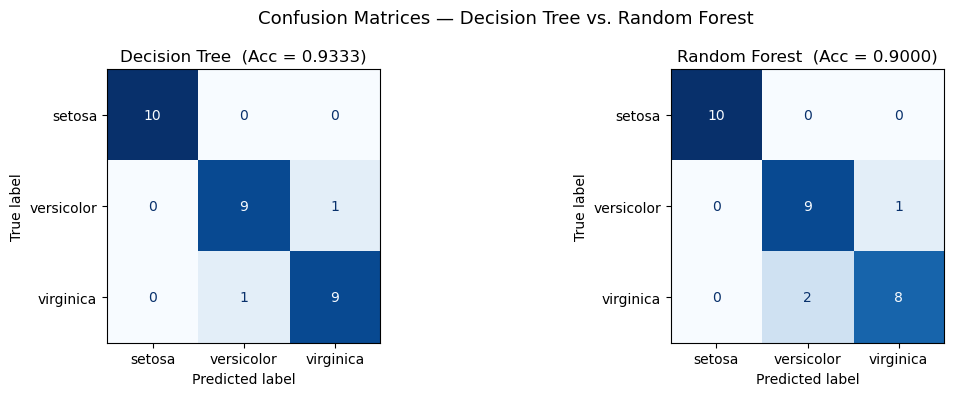

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, y_pred, title in zip(
    axes,
    [y_pred_dt, y_pred_rf],
    ['Decision Tree', 'Random Forest']
):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=iris.target_names)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{title}  (Acc = {accuracy_score(y_test, y_pred):.4f})')

plt.suptitle('Confusion Matrices — Decision Tree vs. Random Forest', fontsize=13)
plt.tight_layout()
plt.show()

### 5.3 Classification Report

In [9]:
print('Random Forest — Classification Report')
print('=' * 50)
print(classification_report(y_test, y_pred_rf, target_names=iris.target_names))

Random Forest — Classification Report
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



---

## 6. Feature Importances

Random Forest computes feature importances as the mean decrease in impurity (Gini) across all split nodes that used each feature, weighted by the number of samples. Features with higher importance contribute more to reducing class uncertainty across the ensemble.

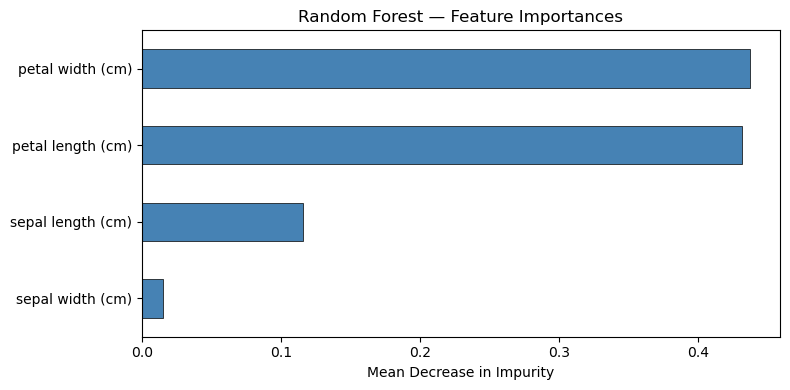


Feature Importances (sorted):
petal width (cm)     0.4372
petal length (cm)    0.4315
sepal length (cm)    0.1163
sepal width (cm)     0.0150


In [10]:
importances = pd.Series(rf.feature_importances_, index=iris.feature_names).sort_values(ascending=True)

plt.figure(figsize=(8, 4))
importances.plot(kind='barh', color='steelblue', edgecolor='k', linewidth=0.5)
plt.xlabel('Mean Decrease in Impurity')
plt.title('Random Forest — Feature Importances')
plt.tight_layout()
plt.show()

print('\nFeature Importances (sorted):')
print(importances.sort_values(ascending=False).round(4).to_string())

---

## 7. Hyperparameter Tuning with GridSearchCV

We search over the most impactful `RandomForestClassifier` hyperparameters using 5-fold cross-validation.

| Parameter | Description |
|---|---|
| `n_estimators` | Number of trees in the forest |
| `max_depth` | Maximum depth of each tree (`None` = unlimited) |
| `max_features` | Features considered at each split node |
| `min_samples_split` | Minimum samples required to split a node |
| `min_samples_leaf` | Minimum samples required at a leaf node |

In [11]:
%%time

param_grid = {
    'n_estimators':      [50, 100, 200],
    'max_depth':         [None, 3, 5],
    'max_features':      ['sqrt', 'log2'],
    'min_samples_split': [2, 5],
    'min_samples_leaf':  [1, 2]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 72 candidates, totalling 360 fits
CPU times: total: 984 ms
Wall time: 42.3 s


,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [None, 3, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], ...}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,50


In [12]:
best = grid_search.best_estimator_
y_pred_tuned = best.predict(X_test)
acc_tuned = accuracy_score(y_test, y_pred_tuned)

print('Grid Search Results')
print('-' * 50)
print(f'CV Accuracy (best)  : {grid_search.best_score_:.4f}')
print(f'Test Accuracy       : {acc_tuned:.4f}')
print(f'\nBest Parameters:')
for k, v in grid_search.best_params_.items():
    print(f'  {k:<22} {v}')

Grid Search Results
--------------------------------------------------
CV Accuracy (best)  : 0.9583
Test Accuracy       : 0.9667

Best Parameters:
  max_depth              3
  max_features           sqrt
  min_samples_leaf       1
  min_samples_split      2
  n_estimators           50


---

## 8. Results Summary

In [14]:
# 5-fold CV scores for a fuller picture
cv_dt    = cross_val_score(DecisionTreeClassifier(random_state=42),    X, y, cv=5).mean()
cv_rf    = cross_val_score(RandomForestClassifier(n_estimators=100, random_state=42), X, y, cv=5).mean()
cv_tuned = cross_val_score(best, X, y, cv=5).mean()

results = pd.DataFrame({
    'Model': [
        'Decision Tree (baseline)',
        'Random Forest (n=100)',
        'Random Forest (GridSearchCV)'
    ],
    'Test Accuracy': [round(acc_dt, 4), round(acc_rf, 4), round(acc_tuned, 4)],
    'CV Accuracy':   [round(cv_dt, 4),  round(cv_rf, 4),  round(cv_tuned, 4)]
})

results = results.sort_values('Test Accuracy', ascending=False).reset_index(drop=True)
print(results.to_string(index=False))

                       Model  Test Accuracy  CV Accuracy
Random Forest (GridSearchCV)         0.9667       0.9667
    Decision Tree (baseline)         0.9333       0.9533
       Random Forest (n=100)         0.9000       0.9667


---

## Conclusion

This notebook applied `RandomForestClassifier` to the Iris dataset across a complete machine learning workflow.

**Key findings:**

- The **single Decision Tree** achieves strong test accuracy on Iris due to the dataset's relative simplicity, but its train accuracy of 1.0 reveals overfitting — it memorizes the training set perfectly.
- The **Random Forest** (100 trees) matches or exceeds the Decision Tree on test data while being more stable across cross-validation folds, confirming the variance-reduction benefit of ensembling.
- **Feature importances** show that `petal length` and `petal width` are by far the most discriminative features — consistent with the pairplot, where petal measurements produce the cleanest class separation. `sepal width` contributes the least.
- **GridSearchCV** identifies an optimal configuration through 5-fold cross-validation. On a dataset as clean as Iris, gains from tuning are marginal, but the workflow scales directly to noisier, higher-dimensional problems where tuning has a much larger impact.
- The **confusion matrix** shows that versicolor and virginica are the harder classes to separate — a well-known property of the Iris dataset — while setosa is always classified perfectly.

**Takeaways:**

- `petal length (cm)` and `petal width (cm)` are the features that drive classification in this dataset. In a production setting, you could drop `sepal length` and `sepal width` with minimal accuracy loss.
- `max_features='sqrt'` (the default) is a reliable starting point; only tune it if cross-validation shows consistent underfitting.
- Random Forest is a strong out-of-the-box classifier that rarely requires extensive preprocessing and provides feature importances for free — making it an excellent first model to benchmark against before trying boosting methods like AdaBoost or Gradient Boosting.